# IVON Hutchinson: how often to estimate the Hessian (`hess_every`)

This notebook fixes the **Hutchinson at-the-mean** estimator and varies a single
knob, `hess_every`, which sets how often the diagonal Hessian is (re)estimated.

- The gradient $\nabla L(\mu)$ is computed on **every** step.
- Every `hess_every` steps the diagonal Hessian is refreshed with one Rademacher
  probe $u \odot (\nabla^2 L(\mu)\,u)$ via a single forward-over-reverse pass
  (`jax.jvp` of `jax.value_and_grad`). On the intervening steps that extra
  Hessian-vector-product pass is **skipped** and the previous Hessian is reused
  (the IVON Hessian EMA reduces to the identity).
- `hess_every=1` reproduces the per-step Hutchinson estimator.

Everything else — the model, data, IVON hyper-parameters and initial weights —
is held fixed and matches `compare_ivon_estimators.ipynb`. Larger `hess_every`
trades a staler curvature estimate for cheaper steps.

The final section repeats the same sweep for **EVON** (`hess_every \in \{1, 5, 10\}`), where the diagonal Hessian is estimated in SOAP's eigenbasis rather than per parameter.

In [1]:
import os

# do not prealocate memory
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

# Set cuda device to use
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
try:
    import matplotlib.pyplot as plt
except:
    !pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    !pip install seaborn
    import seaborn as sns

%matplotlib inline
sns.set_theme(context='notebook', style='white', color_codes=True)

In [3]:
import time
import numpy as np

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
from blrax import ivon, evon, get_scale
from jax import lax, vmap, nn

from data_loaders import load_mnist
from training import run_training

key = jr.PRNGKey(0)

## Data and metrics

Reused from `test_mnist.ipynb`.

In [4]:
train_ds, test_ds = load_mnist()

## Training loop

The same `run_training` as in `compare_ivon_estimators.ipynb`. Here the
estimator is fixed to `'hutchinson'`; the `hess_every` knob lives on the
optimizer (see `make_optim` below), so the training loop itself is unchanged.

In [5]:
def plot_performance(results, num_epochs):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    for name, vals in results.items():
        if vals is not None:
            for ax, lbl in zip(axes, ['acc', 'ece', 'nll']):
                ax.plot(range(1, num_epochs + 1), vals[lbl], 'o:', label=name)
                ax.set_xlabel('epoch')
                ax.set_title(lbl)
    axes[0].legend(title='hess_every', fontsize=11)
    fig.tight_layout()
    return fig

## Model

In [6]:
depth = 5
in_size = 28 * 28
out_size = 10
num_neurons = 1024

NUM_EPOCHS = 30  # raise for sharper curves

key, _key = jr.split(key)
nnet = eqx.nn.MLP(in_size, out_size, num_neurons, depth, key=_key)
datasize = len(train_ds['image'])

## Train Hutchinson at several refresh periods

All runs use the **same** estimator (`hutchinson`), the same IVON
hyper-parameters and the same initial weights; only `hess_every` differs. We
record wall-clock time per run (`jax.block_until_ready` forces the async compute
to finish before we stop the timer; the first epoch includes JIT compilation).

In [7]:
def make_optim(hess_init, hess_every):
    # In hutchinson hessian estimator case we can use lower b2 to get similar estimates of posterior uncertainty
    # over different hessian estimation frequencies. Importantly the acc, nll, ece values stay unchanched. 
    return ivon(1e-2, ess=datasize, hess_init=hess_init, weight_decay=1e-4,
                clip_radius=1e-1, hess_every=hess_every) 
    

HESS_INIT = 0.35
hess_every_values = [1, 2, 4, 6, 8]

results = {}
states = {}
timings = {}

for k_every in hess_every_values:
    name = f'hess_every={k_every}'
    optim = make_optim(HESS_INIT, k_every)
    key, _key = jr.split(key)
    t0 = time.time()
    _, final_opt_state, metrics = run_training(
        _key, nnet, optim, train_ds, test_ds, num_epochs=NUM_EPOCHS, estimator='hutchinson')
    metrics = jax.block_until_ready(metrics)
    dt = time.time() - t0

    results[name] = metrics
    states[name] = final_opt_state
    timings[name] = dt
    print(f"{name:14s} acc={float(metrics['acc'][-1]):.4f}  "
          f"nll={float(metrics['nll'][-1]):.4f}  ece={float(metrics['ece'][-1]):.4f}  "
          f"time={dt:.1f}s")

hess_every=1   acc=0.9790  nll=0.0963  ece=0.0006  time=23.3s
hess_every=2   acc=0.9788  nll=0.0962  ece=0.0006  time=11.8s
hess_every=4   acc=0.9786  nll=0.0958  ece=0.0006  time=10.3s
hess_every=6   acc=0.9786  nll=0.0975  ece=0.0006  time=9.7s
hess_every=8   acc=0.9783  nll=0.0958  ece=0.0007  time=9.4s


## Convergence: accuracy, calibration (ECE), NLL

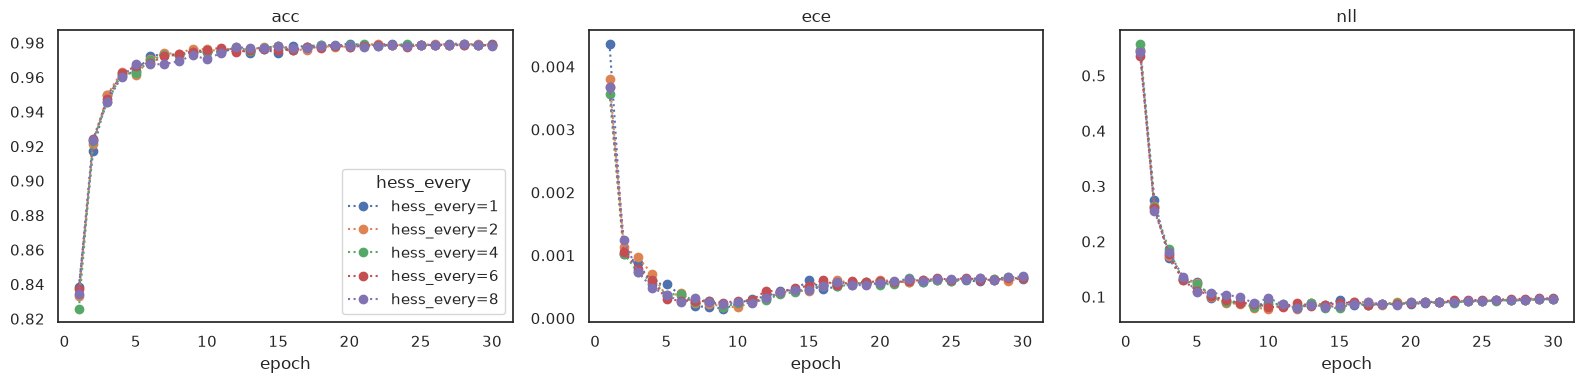

In [8]:
fig = plot_performance(results, NUM_EPOCHS)

## Cost per run

The gradient is computed on every step; the extra Hessian-vector-product pass
runs only every `hess_every` steps (the previous Hessian is reused otherwise).
So wall-clock time falls as `hess_every` grows, heading toward the cost of a
plain first-order step — the HVP roughly doubles the backward pass when it runs.
The first epoch includes JIT compilation, so on this small MLP read the bars
qualitatively; the gap widens with model size.

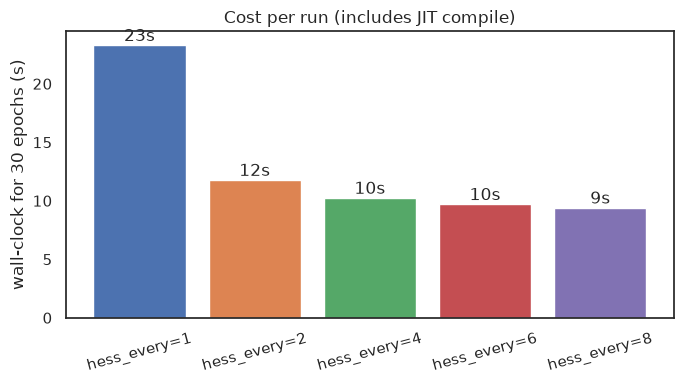

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(timings.keys())
ax.bar(names, [timings[n] for n in names], color=sns.color_palette()[:len(names)])
ax.set_ylabel(f'wall-clock for {NUM_EPOCHS} epochs (s)')
ax.set_title('Cost per run (includes JIT compile)')
for i, n in enumerate(names):
    ax.text(i, timings[n], f"{timings[n]:.0f}s", ha='center', va='bottom')
plt.xticks(rotation=15)
fig.tight_layout()

## Learned posterior uncertainty

IVON's posterior std is $\sigma = 1/\sqrt{\mathrm{ess}\,(h + \lambda)}$
(`get_scale`). A larger `hess_every` refreshes `h` less frequently, so the
curvature — and the learned per-weight uncertainty — can differ from the
per-step estimate.

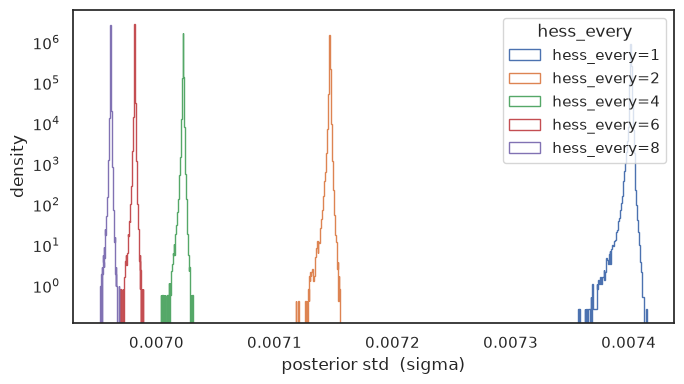

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, final_opt_state in states.items():
    scale = get_scale(final_opt_state[0])
    flat = jnp.concatenate([jnp.ravel(v) for v in jax.tree.leaves(scale)])
    ax.hist(np.asarray(flat), bins=80, histtype='step', density=True, label=name)
ax.set_xlabel('posterior std  (sigma)')
ax.set_ylabel('density')
ax.set_yscale('log')
ax.legend(title='hess_every', fontsize=11)
fig.tight_layout()

## Takeaways

- **One estimator, sparser curvature.** Every run is the Hutchinson at-the-mean
  estimator; only how often the Hessian is refreshed (`hess_every`) changes.
- **`hess_every` buys speed.** The gradient is still computed every step, but the
  extra HVP pass is skipped on the intervening steps, so larger `hess_every`
  lowers wall-clock cost toward a plain first-order step.
- **Trade-off.** A staler Hessian can slow convergence or shift calibration;
  compare the accuracy / ECE / NLL curves to see whether — and where — sparser
  Hessian estimates start to cost accuracy on MNIST.
- **Posterior std follows `h`.** Less frequent Hessian updates change the learned
  uncertainty, visible in the $\sigma$ histograms.

## EVON: how `hess_every` shapes the eigenbasis Hessian

The same study for **EVON** (IVON run inside SOAP's eigenbasis, per 2-D weight
matrix). EVON's Hutchinson estimator draws the Rademacher probe in the eigenbasis,
projects it to parameter space for the HVP, and projects the result back, so
`h_hat` estimates the *eigenbasis* diagonal Hessian. That HVP is gated by
`hess_every`, aligned with the eigenbasis refresh `precond_every`. Here
`precond_every=10` is fixed and we sweep `hess_every` in `{1, 5, 10}` (each
divides `precond_every`, so the estimates stay phase-aligned with the refreshes):
`hess_every=1` re-estimates every step, `hess_every=10` only when the basis
refreshes. EVON uses its default `b2=0.95` (the paper's `1 - b2 = 0.05`), so a
sparser Hessian shows up more clearly than with IVON's longer-memory EMA above.

In [23]:
def make_evon_optim(hess_init, hess_every, b2=0.9999):
    # EVON keeps its default b2=0.95 (paper's 1-b2=0.05); precond_every is fixed
    # at 10 so hess_every in {1, 5, 10} stays phase-aligned with the eigenbasis
    # refresh (an estimate lands on every refresh step).
    b2_eff = b2 ** hess_every
    return evon(1e-2, ess=datasize, hess_init=hess_init, weight_decay=1e-4,
                clip_radius=1e-1, precond_every=10, hess_every=hess_every, b2=b2_eff)


evon_hess_every_values = [1, 5, 10]

evon_results = {}
evon_states = {}
evon_timings = {}

for k_every in evon_hess_every_values:

    if k_every == 1:
        optim = make_evon_optim(HESS_INIT, k_every)
        key, _key = jr.split(key)
        t0 = time.time()
        _, final_opt_state, metrics = run_training(
            _key, nnet, optim, train_ds, test_ds, num_epochs=NUM_EPOCHS, estimator='sampling')
        metrics = jax.block_until_ready(metrics)
        dt = time.time() - t0

        name = 'smpl-base'
        evon_results[name] = metrics
        evon_states[name] = final_opt_state
        evon_timings[name] = dt
        print(f"{name:14s} acc={float(metrics['acc'][-1]):.4f}  "
            f"nll={float(metrics['nll'][-1]):.4f}  ece={float(metrics['ece'][-1]):.4f}  "
            f"time={dt:.1f}s")

    name = f'hess_every={k_every}'
    optim = make_evon_optim(HESS_INIT, k_every)
    key, _key = jr.split(key)
    t0 = time.time()
    _, final_opt_state, metrics = run_training(
        _key, nnet, optim, train_ds, test_ds, num_epochs=NUM_EPOCHS, estimator='hutchinson')
    metrics = jax.block_until_ready(metrics)
    dt = time.time() - t0        

    evon_results[name] = metrics
    evon_states[name] = final_opt_state
    evon_timings[name] = dt
    print(f"{name:14s} acc={float(metrics['acc'][-1]):.4f}  "
          f"nll={float(metrics['nll'][-1]):.4f}  ece={float(metrics['ece'][-1]):.4f}  "
          f"time={dt:.1f}s")

smpl-base      acc=0.9825  nll=0.0783  ece=0.0005  time=105.9s
hess_every=1   acc=0.9770  nll=0.0999  ece=0.0007  time=161.6s
hess_every=5   acc=0.9756  nll=0.1208  ece=0.0008  time=104.5s
hess_every=10  acc=0.9808  nll=0.0943  ece=0.0006  time=103.1s


### Convergence (EVON): accuracy, calibration (ECE), NLL

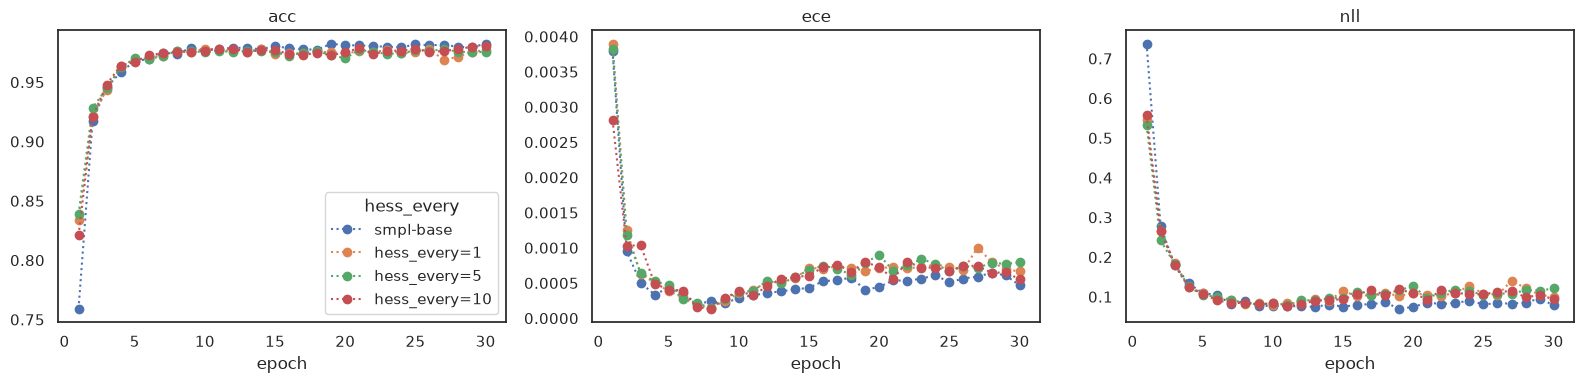

In [24]:
fig = plot_performance(evon_results, NUM_EPOCHS)

### EVON: posterior uncertainty / Hessian distribution

EVON's `get_scale` returns the **parameter-space** marginal std obtained by
projecting the eigenbasis variances `V = 1 / (ess * (H + lambda))` back through
the per-matrix bases (`QL**2`, `QR**2`). As `sigma` is monotone in `H`, this
histogram is the learned-uncertainty view of the eigenbasis Hessian: a larger
`hess_every` refreshes `H` less often, shifting the distribution.

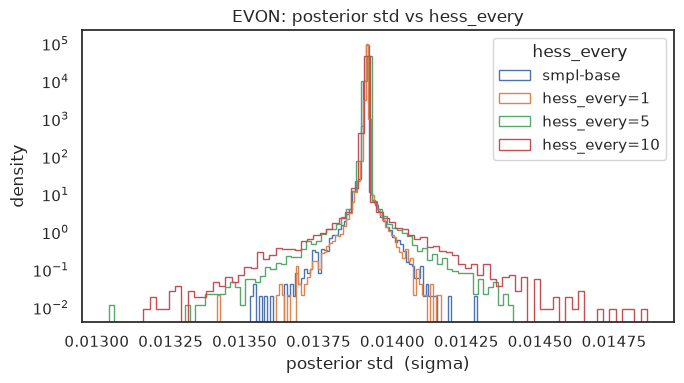

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, final_opt_state in evon_states.items():
    scale = get_scale(final_opt_state[0])
    flat = jnp.concatenate([jnp.ravel(v) for v in jax.tree.leaves(scale)])
    ax.hist(np.asarray(flat), bins=80, histtype='step', density=True, label=name)
ax.set_xlabel('posterior std  (sigma)')
ax.set_ylabel('density')
ax.set_yscale('log')
ax.set_title('EVON: posterior std vs hess_every')
ax.legend(title='hess_every', fontsize=11)
fig.tight_layout()